# Feature Engineering & Feature Importance Testing

In [145]:
# import the library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeRegressor
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder

In [146]:
# Load the data
df = pd.read_csv('outputs/train_cleaned_trimmed.csv')

# Review the shape of the data
print(df.shape)

(1460, 75)


In [147]:
# Apply log transformation to the target variable for testing
df['SalePrice_Log'] = np.log1p(df['SalePrice'])

## Creation of Interaction Features

### Continuous Data

In [148]:
# Create a feature called InternalSF
df['InternalSF'] = df['1stFlrSF'] + df['2ndFlrSF'] + df['TotalBsmtSF']

# Create PorchDeckSF feature
df['PorchDeckSF'] = df['OpenPorchSF'] + df['EnclosedPorch'] + df['3SsnPorch'] + df['ScreenPorch'] + df['WoodDeckSF']

# Create the feature TotalBathrooms
df['TotalBath'] = df['BsmtFullBath'] + (df['BsmtHalfBath'] * 0.5) + df['FullBath'] + (df['HalfBath'] * 0.5)

# Total rooms and bathrooms above ground
df['TotRmsAbvGrdWithBath'] = df['TotRmsAbvGrd'] + df['FullBath'] + (df['HalfBath'] * 0.5)

# Quality of total living area 
df['InternalQual'] = df['OverallQual'] * df['InternalSF']

# Condition of total living area
df['InternalCond'] = df['OverallCond'] * df['InternalSF']

# Create a column called HouseAge
df['HouseAge'] = df['YrSold'] - df['YearBuilt']

# Create a column called RemodAge
df['RemodAge'] = df['YrSold'] - df['YearRemodAdd']

# Create a column called GarageAge
df['GarageAge'] = df['YrSold'] - df['GarageYrBlt']

In [149]:
# Mapping dictionary
qual_mapping = {
    'Ex': 5,
    'Gd': 4,
    'TA': 3,
    'Fa': 2,
    'Po': 1,
    'NA': 0  # Use same value as 'TA' for 'Not Applicable'
}

# List of columns to update
cols = ['ExterQual', 'ExterCond', 'HeatingQC', 'KitchenQual', 'GarageQual', 'GarageCond']

# Apply mapping to each column in the list
for col in cols:
    df[col + 'Rank'] = df[col].map(qual_mapping)

In [150]:
# Create additional interaction features
df['ExterQaulScore'] = df['MasVnrArea'] * df['ExterQualRank']
df['ExterCondScore'] = df['MasVnrArea'] * df['ExterCondRank']
df['HeatingQCScore'] = df['GrLivArea'] * df['HeatingQCRank']
df['KitchenQualScore'] = df['GrLivArea'] * df['KitchenQualRank']
df['GarageQualScore'] = df['GarageArea'] * df['GarageQualRank']
df['GarageCondScore'] = df['GarageArea'] * df['GarageCondRank']

In [151]:
# Drop the ranking columns
df.drop([col + 'Rank' for col in cols], axis=1, inplace=True)

In [152]:
# Check for missing data
# Show the features in the data that have missing values and the number of missing values
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]

# Get the data types of the features with missing values
missing_values_data_types = df.dtypes[missing_values.index]

# Combine the missing values and data types into a single DataFrame
missing_values_info = pd.DataFrame({'Missing Values': missing_values, 'Data Type': missing_values_data_types})

print(missing_values_info)

                 Missing Values Data Type
GarageQualScore              81   float64
GarageCondScore              81   float64


In [153]:
# Replace the missing values with the medain
# List of columns to fill missing values
columns = ['GarageQualScore', 'GarageCondScore']

# Loop through each column and fill missing values with the median
for column in columns:
    df[column] = df[column].fillna(df[column].median())

### Test for correlation

In [155]:
# Create a dataframe for the continuous variables
continuous_data = df.select_dtypes(include='number')

# drop the Id and SalePrice columns
continuous_data.drop(['Id', 'SalePrice'], axis=1, inplace=True)

# Display the first 5 rows of the continuous data
continuous_data.head()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,InternalCond,HouseAge,RemodAge,GarageAge,ExterQaulScore,ExterCondScore,HeatingQCScore,KitchenQualScore,GarageQualScore,GarageCondScore
0,60,65.0,8450,7,5,2003,2003,196.0,706,0,...,12830,5,5,5.0,784.0,588.0,8550,6840,1644.0,1644.0
1,20,80.0,9600,6,8,1976,1976,0.0,978,0,...,20192,31,31,31.0,0.0,0.0,6310,3786,1380.0,1380.0
2,60,68.0,11250,7,5,2001,2002,162.0,486,0,...,13530,7,6,7.0,648.0,486.0,8930,7144,1824.0,1824.0
3,70,60.0,9550,7,5,1915,1970,0.0,216,0,...,12365,91,36,8.0,0.0,0.0,6868,6868,1926.0,1926.0
4,60,84.0,14260,8,5,2000,2000,350.0,655,0,...,16715,8,8,8.0,1400.0,1050.0,10990,8792,2508.0,2508.0


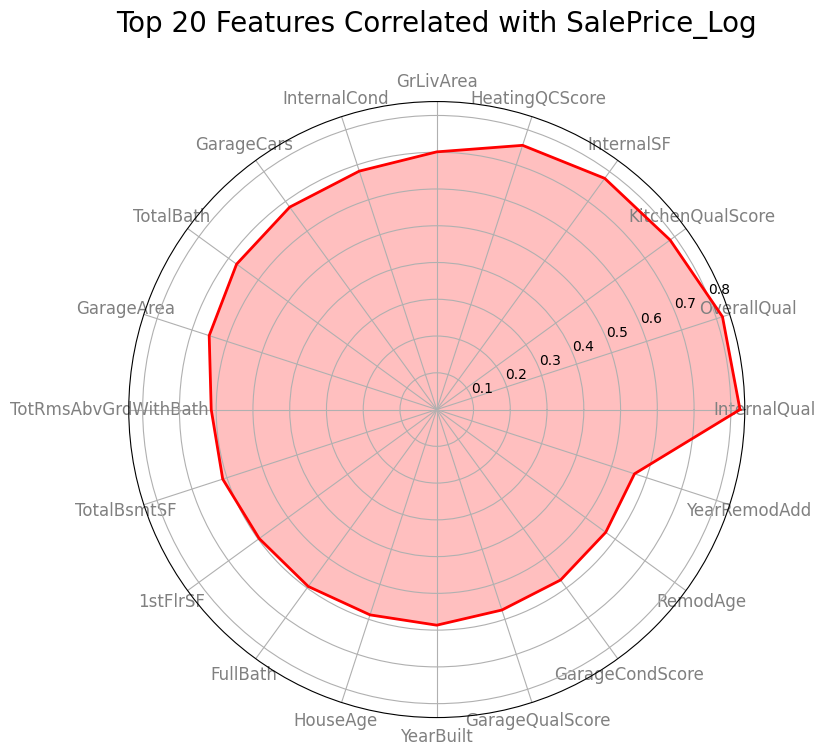

In [156]:
# Compute correlation
correlation_matrix = continuous_data.corr()

# Get correlation of all features with SalesPrice
correlation_with_salesprice = correlation_matrix['SalePrice_Log'].drop('SalePrice_Log')

# Sort correlations in descending order
correlation_ranked = correlation_with_salesprice.abs().sort_values(ascending=False)

# Select the top 20 features
top_20_features = correlation_ranked.head(20)

# Create a radar chart
categories = top_20_features.index
values = top_20_features.values

# Ensure the radar chart is circular
angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()
values = np.concatenate((values, [values[0]]))
angles += angles[:1]

# Plot
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
plt.xticks(angles[:-1], categories, color='grey', size=12)
ax.fill(angles, values, color='red', alpha=0.25)
ax.plot(angles, values, color='red', linewidth=2)

plt.title('Top 20 Features Correlated with SalePrice_Log', size=20, color='black', y=1.1)
plt.show()

In [157]:
print(correlation_ranked)

InternalQual            0.824875
OverallQual             0.817218
KitchenQualScore        0.784620
InternalSF              0.777359
HeatingQCScore          0.755739
GrLivArea               0.700988
InternalCond            0.681989
GarageCars              0.680632
TotalBath               0.673020
GarageArea              0.650907
TotRmsAbvGrdWithBath    0.613544
TotalBsmtSF             0.612180
1stFlrSF                0.597034
FullBath                0.594786
HouseAge                0.587271
YearBuilt               0.586551
GarageQualScore         0.573378
GarageCondScore         0.573106
RemodAge                0.568118
YearRemodAdd            0.565590
TotRmsAbvGrd            0.534459
GarageAge               0.497095
GarageYrBlt             0.495816
Fireplaces              0.489466
ExterQaulScore          0.474972
MasVnrArea              0.426858
ExterCondScore          0.422710
PorchDeckSF             0.398420
BsmtFinSF1              0.372059
LotFrontage             0.335316
WoodDeckSF

### Drop continuous features with a very low correlation score (Less than 0.3)

In [158]:
# Define correlation threshold
correlation_threshold = 0.3

# Identify features with correlation below the threshold
low_correlation_features = correlation_ranked[correlation_ranked < correlation_threshold].index.tolist()

# Drop these features from the DataFrame
df_cleaned = df.drop(columns=low_correlation_features)

# Print confirmation message
print(f"Dropped {len(low_correlation_features)} features with correlation below {correlation_threshold}.")
print("Remaining features in df_cleaned:")
print(df_cleaned.columns)


Dropped 17 features with correlation below 0.3.
Remaining features in df_cleaned:
Index(['Id', 'MSZoning', 'LotFrontage', 'LotShape', 'LandContour', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'BldgType', 'HouseStyle',
       'OverallQual', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl',
       'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual',
       'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure',
       'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'GrLivArea', 'FullBath', 'HalfBath', 'KitchenQual', 'TotRmsAbvGrd',
       'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt',
       'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond',
       'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'Fence', 'SaleType',
       'SaleCondition', 'SalePrice', 'SalePrice_Log', 'InternalSF',
       'Por

### Test for Multicollinearity on the remain features

In [159]:
import pandas as pd
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler

# Step 1: Define the target variable
target_col = 'SalePrice_Log'  # Change this if your target column name is different

# Step 2: Drop non-numeric columns and target column
features = df_cleaned.drop(columns=[target_col])
features = features.select_dtypes(include=[np.number])  # Keep only numeric columns

# Step 3: Handle missing and infinite values
features.replace([np.inf, -np.inf], np.nan, inplace=True)  # Convert inf to NaN
features.fillna(features.median(), inplace=True)  # Fill NaNs with column median

# Step 4: Standardize the data (optional but recommended for VIF)
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Step 5: Compute VIF for each feature
vif_data = pd.DataFrame()
vif_data["Feature"] = features.columns
vif_data["VIF"] = [variance_inflation_factor(features_scaled, i) for i in range(features_scaled.shape[1])]

# Step 6: Identify features with `inf` VIF
inf_vif_features = vif_data[vif_data["VIF"] == np.inf]["Feature"].tolist()

# Step 7: Drop these features from the dataset
df_cleaned_vif = df_cleaned.drop(columns=inf_vif_features)

# Step 8: Print results
print(f"\nDropped {len(inf_vif_features)} features due to infinite VIF values:")
print(inf_vif_features)
print("\nRemaining Features in df_cleaned_vif:")
print(df_cleaned_vif.columns)


c:\Users\Carl\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)



Dropped 14 features due to infinite VIF values:
['YearBuilt', 'YearRemodAdd', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'FullBath', 'HalfBath', 'TotRmsAbvGrd', 'GarageYrBlt', 'InternalSF', 'TotRmsAbvGrdWithBath', 'HouseAge', 'RemodAge', 'GarageAge']

Remaining Features in df_cleaned_vif:
Index(['Id', 'MSZoning', 'LotFrontage', 'LotShape', 'LandContour', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'BldgType', 'HouseStyle',
       'OverallQual', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd',
       'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical',
       'GrLivArea', 'KitchenQual', 'Functional', 'Fireplaces', 'FireplaceQu',
       'GarageType', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'Fence',
       'SaleType', 'Sal

In [160]:
# Drop the GarageCondScore feature as it is too correlated to GarageQualScore
df_cleaned_vif.drop('GarageCondScore', axis=1, inplace=True)

### Review the correlation of Continuous Features

In [161]:
# Create a dataframe for the continuous variables
continuous_data1 = df_cleaned_vif.select_dtypes(include='number')

# drop the Id column
continuous_data1.drop('Id', axis=1, inplace=True)

# Display the first 5 rows of the continuous data
continuous_data1.head()

,LotFrontage,OverallQual,MasVnrArea,BsmtFinSF1,GrLivArea,Fireplaces,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,...,SalePrice_Log,PorchDeckSF,TotalBath,InternalQual,InternalCond,ExterQaulScore,ExterCondScore,HeatingQCScore,KitchenQualScore,GarageQualScore
0,65.0,7,196.0,706,1710,0,2,548,0,61,...,6.126035,61,3.5,17962,12830,784.0,588.0,8550,6840,1644.0
1,80.0,6,0.0,978,1262,1,2,460,298,0,...,6.056850,298,2.5,15144,20192,0.0,0.0,6310,3786,1380.0
2,68.0,7,162.0,486,1786,1,2,608,0,42,...,6.160696,42,3.5,18942,13530,648.0,486.0,8930,7144,1824.0
3,60.0,7,0.0,216,1717,1,3,642,0,35,...,5.927368,307,2.0,17311,12365,0.0,0.0,6868,6868,1926.0
4,84.0,8,350.0,655,2198,1,3,836,192,84,...,6.216606,276,3.5,26744,16715,1400.0,1050.0,10990,8792,2508.0


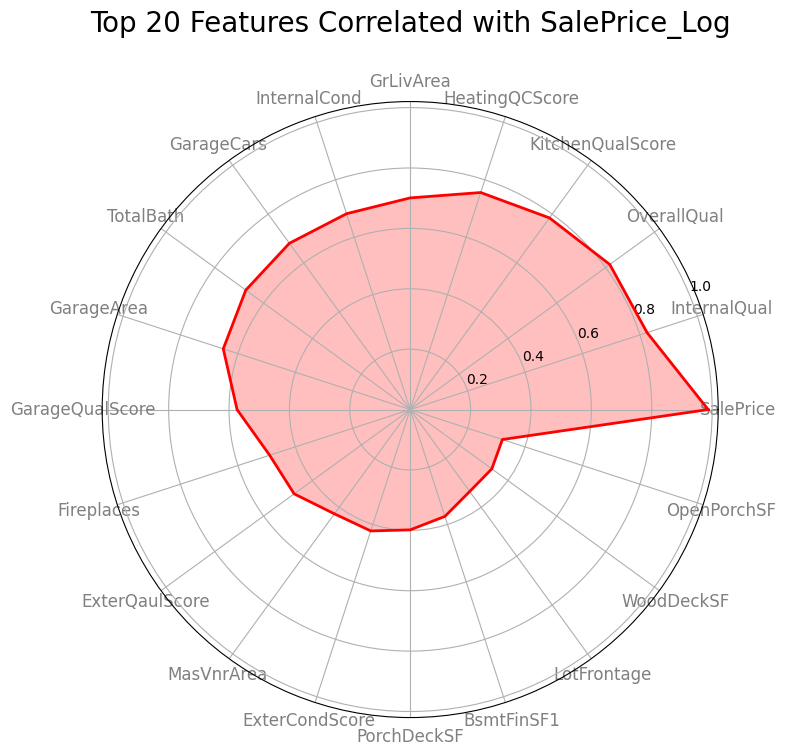

In [162]:
# Compute correlation
correlation_matrix = continuous_data1.corr()

# Get correlation of all features with SalesPrice
correlation_with_salesprice = correlation_matrix['SalePrice_Log'].drop('SalePrice_Log')

# Sort correlations in descending order
correlation_ranked = correlation_with_salesprice.abs().sort_values(ascending=False)

# Select the top 20 features
top_20_features = correlation_ranked.head(20)

# Create a radar chart
categories = top_20_features.index
values = top_20_features.values

# Ensure the radar chart is circular
angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()
values = np.concatenate((values, [values[0]]))
angles += angles[:1]

# Plot
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
plt.xticks(angles[:-1], categories, color='grey', size=12)
ax.fill(angles, values, color='red', alpha=0.25)
ax.plot(angles, values, color='red', linewidth=2)

plt.title('Top 20 Features Correlated with SalePrice_Log', size=20, color='black', y=1.1)
plt.show()

In [163]:
print(correlation_ranked)

SalePrice           0.986763
InternalQual        0.824875
OverallQual         0.817218
KitchenQualScore    0.784620
HeatingQCScore      0.755739
GrLivArea           0.700988
InternalCond        0.681989
GarageCars          0.680632
TotalBath           0.673020
GarageArea          0.650907
GarageQualScore     0.573378
Fireplaces          0.489466
ExterQaulScore      0.474972
MasVnrArea          0.426858
ExterCondScore      0.422710
PorchDeckSF         0.398420
BsmtFinSF1          0.372059
LotFrontage         0.335316
WoodDeckSF          0.334152
OpenPorchSF         0.321095
Name: SalePrice_Log, dtype: float64


### Categorical Data

In [164]:
df = df_cleaned_vif

In [165]:
# Step 1: Compute the median SalePrice per Neighborhood
neighborhood_prices = df.groupby('Neighborhood')['SalePrice_Log'].median()

# Step 2: Calculate percentiles based on SalePrice
percentiles = neighborhood_prices.rank(pct=True)

# Step 3: Assign bucket levels
def assign_bucket(pct):
    if pct < 0.2:
        return 'Level_1'
    elif pct < 0.4:
        return 'Level_2'
    elif pct < 0.6:
        return 'Level_3'
    elif pct < 0.8:
        return 'Level_4'
    else:
        return 'Level_5'

# Step 4: Create a mapping dictionary
neighborhood_price_buckets = percentiles.apply(assign_bucket)

# Step 5: Merge back into the original DataFrame
df['Neighborhood_Price_Bucket'] = df['Neighborhood'].map(neighborhood_price_buckets)

In [166]:
# To be used when creating the data for the test
# Convert to DataFrame for better readability
neighborhoods_per_level_df = (
    df[['Neighborhood', 'Neighborhood_Price_Bucket']]
    .drop_duplicates()
    .groupby('Neighborhood_Price_Bucket')['Neighborhood']
    .apply(list)
    .reset_index()
)

# Display the result
print(neighborhoods_per_level_df)

# Drop the neihgborhood column
df = df.drop('Neighborhood', axis=1)

  Neighborhood_Price_Bucket                                       Neighborhood
0                   Level_1                 [OldTown, IDOTRR, MeadowV, BrDale]
1                   Level_2         [BrkSide, Sawyer, Edwards, SWISU, Blueste]
2                   Level_3        [Mitchel, NAmes, SawyerW, Gilbert, NPkVill]
3                   Level_4       [CollgCr, Crawfor, NWAmes, ClearCr, Blmngtn]
4                   Level_5  [Veenker, NoRidge, Somerst, NridgHt, Timber, S...


In [167]:
# Create buckets for bassed on initial data exploration
df['RoofStyle'] = df['RoofStyle'].apply(lambda x: x if x in ['Gable', 'Hip'] else 'Other')

df['RoofMatl'] = df['RoofMatl'].apply(lambda x: x if x == 'CompShg' else 'Other')

df['ExterCond'] = df['ExterCond'].map(lambda x: 
    'Normal' if x == 'TA' else 
    'Above Normal' if x in ['Gd', 'Ex'] else 
    'Below Normal')

df['BsmtFinType2'] = df['BsmtFinType2'].apply(lambda x: x if x in ['Unf', 'ALQ', 'GLQ'] else 'Other')

df['Heating'] = df['Heating'].apply(lambda x: x if x == 'GasA' else 'Other')

df['Electrical'] = df['Electrical'].apply(lambda x: x if x == 'SBrkr' else 'Other')

df['Functional'] = df['Functional'].apply(lambda x: x if x == 'Typ' else 'Other')

df['GarageQual'] = df['GarageQual'].apply(lambda x: x if x in ['TA', 'GD'] else 'Other')

df['GarageCond'] = df['GarageCond'].apply(lambda x: x if x in ['TA', 'GD'] else 'Other')

In [168]:
# Identify categorical columns (excluding 'SalePrice')
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

# Separate categorical data
categorical_data = df[categorical_cols]

# One-Hot Encoder with automatic column naming
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')  
df_encoded = pd.DataFrame(ohe.fit_transform(categorical_data), 
                          columns=ohe.get_feature_names_out(categorical_cols), 
                          index=df.index)

# Keep 'SalePrice' and merge encoded categorical data
df_cat = pd.concat([df[['SalePrice_Log']], df_encoded], axis=1)

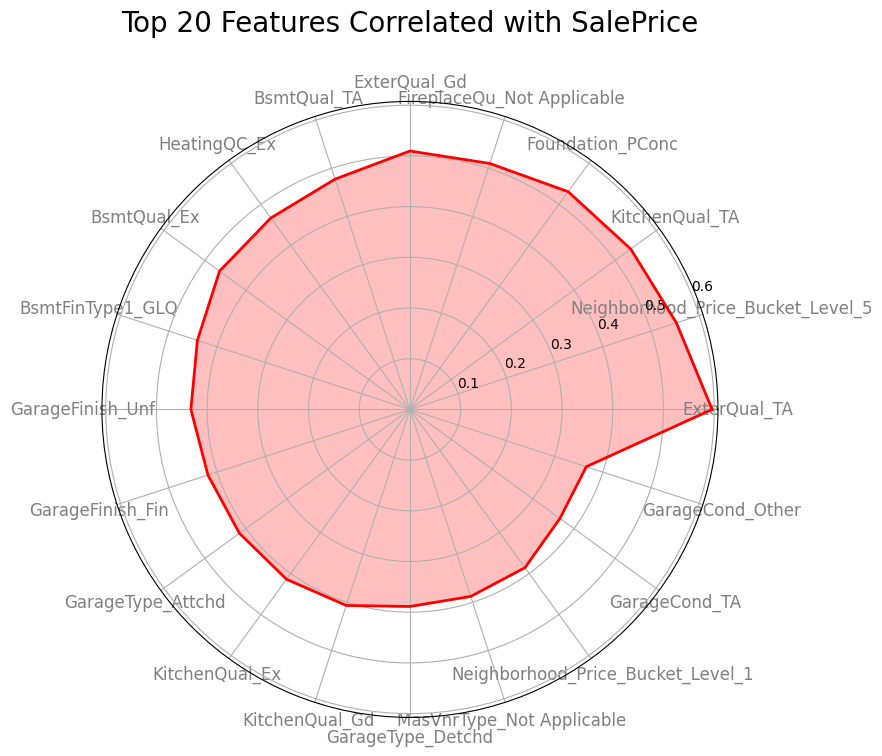

In [170]:
# Compute correlation
correlation_matrix = df_cat.corr()

# Get correlation of all features with SalesPrice
correlation_with_salesprice = correlation_matrix['SalePrice_Log'].drop('SalePrice_Log')

# Sort correlations in descending order
correlation_ranked = correlation_with_salesprice.abs().sort_values(ascending=False)

# Select the top 20 features
top_20_features = correlation_ranked.head(20)

# Create a radar chart
categories = top_20_features.index
values = top_20_features.values

# Ensure the radar chart is circular
angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()
values = np.concatenate((values, [values[0]]))
angles += angles[:1]

# Plot
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
plt.xticks(angles[:-1], categories, color='grey', size=12)
ax.fill(angles, values, color='red', alpha=0.25)
ax.plot(angles, values, color='red', linewidth=2)

plt.title('Top 20 Features Correlated with SalePrice', size=20, color='black', y=1.1)
plt.show()

In [171]:
print(correlation_ranked)

ExterQual_TA                         0.595954
Neighborhood_Price_Bucket_Level_5    0.552558
KitchenQual_TA                       0.538286
Foundation_PConc                     0.530859
FireplaceQu_Not Applicable           0.510030
                                       ...   
LotConfig_FR2                        0.004867
RoofStyle_Other                      0.004585
LotConfig_Corner                     0.003979
SaleType_ConLI                       0.003067
BsmtFinType2_GLQ                     0.002346
Name: SalePrice_Log, Length: 188, dtype: float64


In [172]:
# Identify categorical columns (excluding 'SalePrice')
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

# Separate categorical and continuous data
categorical_data = df[categorical_cols]
continuous_data = df.drop(columns=categorical_cols, errors='ignore')

# Function to encode categorical columns
def encode_columns(df, cols_to_encode):
    ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')  # Avoids errors from unseen categories
    df_encoded = df.copy()
    
    for col in cols_to_encode:
        Xd = ohe.fit_transform(df_encoded[[col]])  # One-hot encode the column
        unique_values = ohe.categories_[0]  # Get unique category names
        new_cols = [f"{col}_{val}" for val in unique_values]  # Create new column names
        
        # Create a new DataFrame for encoded columns
        df_ohe = pd.DataFrame(Xd, columns=new_cols, index=df_encoded.index)
        
        # Concatenate with the original DataFrame
        df_encoded = pd.concat([df_encoded, df_ohe], axis=1)

    # Drop original categorical columns
    df_encoded.drop(cols_to_encode, axis=1, inplace=True)
    
    return df_encoded

# Encode the categorical dataset
df_encoded = encode_columns(categorical_data, categorical_cols)

# Merge encoded categorical data with continuous data
df_final = pd.concat([continuous_data, df_encoded], axis=1)

# Display the first 5 rows of the final dataset
df_final.head()

,Id,LotFrontage,OverallQual,MasVnrArea,BsmtFinSF1,GrLivArea,Fireplaces,GarageCars,GarageArea,WoodDeckSF,...,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial,Neighborhood_Price_Bucket_Level_1,Neighborhood_Price_Bucket_Level_2,Neighborhood_Price_Bucket_Level_3,Neighborhood_Price_Bucket_Level_4,Neighborhood_Price_Bucket_Level_5
0,1,65.0,7,196.0,706,1710,0,2,548,0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,2,80.0,6,0.0,978,1262,1,2,460,298,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2,3,68.0,7,162.0,486,1786,1,2,608,0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,4,60.0,7,0.0,216,1717,1,3,642,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,5,84.0,8,350.0,655,2198,1,3,836,192,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


In [173]:
# Define correlation threshold
correlation_threshold = 0.3

# Identify features with correlation below the threshold
low_correlation_features = correlation_ranked[correlation_ranked < correlation_threshold].index.tolist()

# Drop these features from the DataFrame
df_cleaned = df_final.drop(columns=low_correlation_features)

# Print confirmation message
print(f"Dropped {len(low_correlation_features)} features with correlation below {correlation_threshold}.")
print("Remaining features in df_cleaned:")
print(df_cleaned.columns)

Dropped 148 features with correlation below 0.3.
Remaining features in df_cleaned:
Index(['Id', 'LotFrontage', 'OverallQual', 'MasVnrArea', 'BsmtFinSF1',
       'GrLivArea', 'Fireplaces', 'GarageCars', 'GarageArea', 'WoodDeckSF',
       'OpenPorchSF', 'SalePrice', 'SalePrice_Log', 'PorchDeckSF', 'TotalBath',
       'InternalQual', 'InternalCond', 'ExterQaulScore', 'ExterCondScore',
       'HeatingQCScore', 'KitchenQualScore', 'GarageQualScore', 'MSZoning_RM',
       'Exterior1st_VinylSd', 'Exterior2nd_VinylSd',
       'MasVnrType_Not Applicable', 'MasVnrType_Stone', 'ExterQual_Ex',
       'ExterQual_Gd', 'ExterQual_TA', 'Foundation_CBlock', 'Foundation_PConc',
       'BsmtQual_Ex', 'BsmtQual_Gd', 'BsmtQual_TA', 'BsmtFinType1_GLQ',
       'HeatingQC_Ex', 'HeatingQC_TA', 'CentralAir_N', 'CentralAir_Y',
       'Electrical_Other', 'Electrical_SBrkr', 'KitchenQual_Ex',
       'KitchenQual_Gd', 'KitchenQual_TA', 'FireplaceQu_Gd',
       'FireplaceQu_Not Applicable', 'GarageType_Attchd', 'Gar

In [174]:
# Drop the id column
df_cleaned.drop('Id', axis=1, inplace=True)

# View the first 5 rows of the cleaned data
df_cleaned.head()

,LotFrontage,OverallQual,MasVnrArea,BsmtFinSF1,GrLivArea,Fireplaces,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,...,GarageFinish_Unf,GarageQual_Other,GarageQual_TA,GarageCond_Other,GarageCond_TA,SaleType_New,SaleCondition_Partial,Neighborhood_Price_Bucket_Level_1,Neighborhood_Price_Bucket_Level_2,Neighborhood_Price_Bucket_Level_5
0,65.0,7,196.0,706,1710,0,2,548,0,61,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,80.0,6,0.0,978,1262,1,2,460,298,0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,68.0,7,162.0,486,1786,1,2,608,0,42,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,60.0,7,0.0,216,1717,1,3,642,0,35,...,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,84.0,8,350.0,655,2198,1,3,836,192,84,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


In [175]:
# make a copy of the df_cleaned
df = df_cleaned.copy()

In [176]:
# Export the cleaned data for modelling
df.to_csv('outputs/train_cleaned_encoded.csv', index=False)

## Feature Importance Testing

In [ ]:
# Remove the outliers from the data using the IQR method
# Calculate Q1 (25th percentile) and Q3 (75th percentile)
Q1 = df['SalePrice_Log'].quantile(0.25)
Q3 = df['SalePrice_Log'].quantile(0.75)

# Compute the Interquartile Range (IQR)
IQR = Q3 - Q1

# Define the lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter out the outliers
df = df[(df['SalePrice_Log'] >= lower_bound) & (df['SalePrice_Log'] <= upper_bound)]


## Full Dataset

#### SHAP

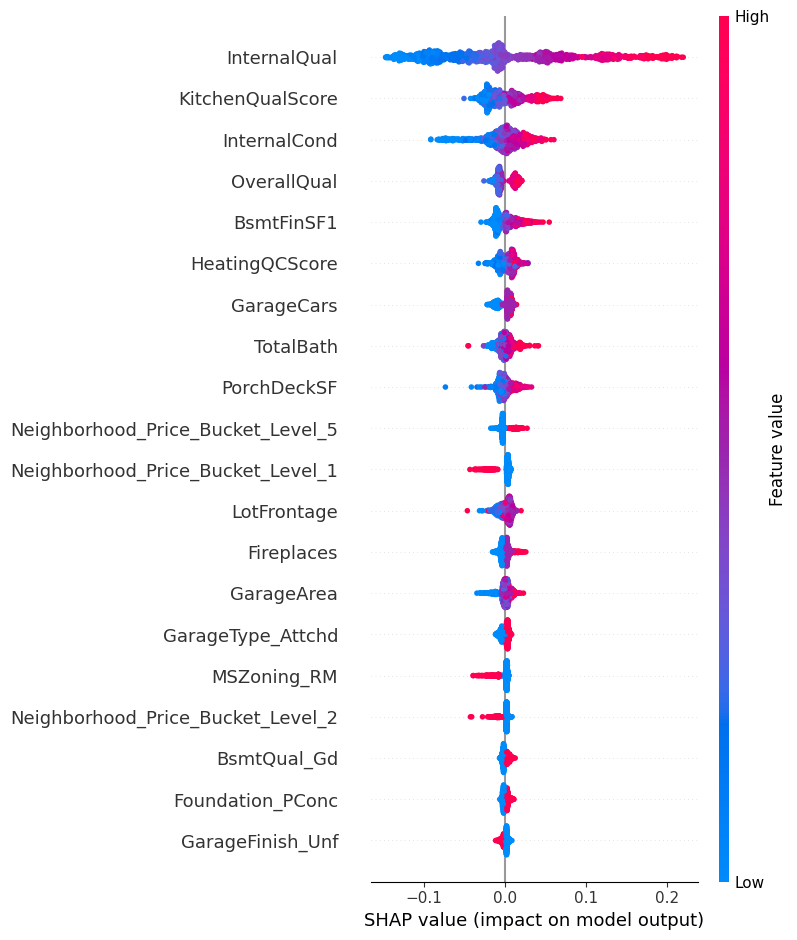

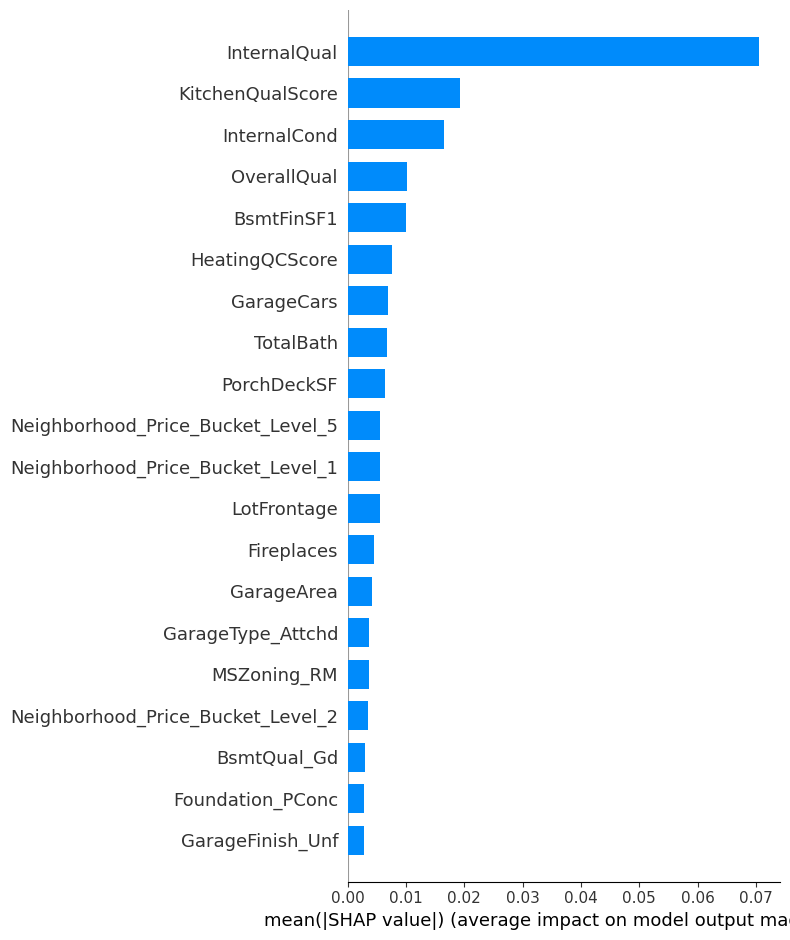

Feature Names: ['LotFrontage', 'OverallQual', 'MasVnrArea', 'BsmtFinSF1', 'GrLivArea', 'Fireplaces', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'PorchDeckSF', 'TotalBath', 'InternalQual', 'InternalCond', 'ExterQaulScore', 'ExterCondScore', 'HeatingQCScore', 'KitchenQualScore', 'GarageQualScore', 'MSZoning_RM', 'Exterior1st_VinylSd', 'Exterior2nd_VinylSd', 'MasVnrType_Not Applicable', 'MasVnrType_Stone', 'ExterQual_Ex', 'ExterQual_Gd', 'ExterQual_TA', 'Foundation_CBlock', 'Foundation_PConc', 'BsmtQual_Ex', 'BsmtQual_Gd', 'BsmtQual_TA', 'BsmtFinType1_GLQ', 'HeatingQC_Ex', 'HeatingQC_TA', 'CentralAir_N', 'CentralAir_Y', 'Electrical_Other', 'Electrical_SBrkr', 'KitchenQual_Ex', 'KitchenQual_Gd', 'KitchenQual_TA', 'FireplaceQu_Gd', 'FireplaceQu_Not Applicable', 'GarageType_Attchd', 'GarageType_Detchd', 'GarageType_Not Applicable', 'GarageFinish_Fin', 'GarageFinish_Not Applicable', 'GarageFinish_Unf', 'GarageQual_Other', 'GarageQual_TA', 'GarageCond_Other', 'GarageCond_TA', 'Sa

In [179]:
import shap
import xgboost as xgb
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Drop the 'SalePrice' column
df.drop('SalePrice', axis=1, inplace=True)

# Select relevant features (exclude 'SalePrice' or your target column)
X = df.drop(columns=['SalePrice_Log'])
y = df['SalePrice_Log']

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Handle missing values by filling with the median
X_train.fillna(X_train.median(), inplace=True)
X_test.fillna(X_test.median(), inplace=True)

# Feature scaling (optional)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define the model (use the parameters you've already tuned or defined)
params = {
    'objective': 'reg:squarederror',
    'eval_metric': 'rmse',
    'max_depth': 6,
    'learning_rate': 0.1,
    'n_estimators': 100,
    'subsample': 0.8,
    'colsample_bytree': 0.8
}

model = xgb.XGBRegressor(**params)

# Train the XGBoost model
model.fit(X_train_scaled, y_train)

# SHAP Values for Model Interpretability
explainer = shap.Explainer(model)
shap_values = explainer(X_train_scaled)

# SHAP Summary Plot with Feature Names
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_train_scaled, feature_names=X.columns)
plt.show()

# SHAP bar plot for top 10 features
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_train_scaled, plot_type="bar", feature_names=X.columns)
plt.show()

# Print the feature names
print("Feature Names:", list(X.columns))

# Compute the mean absolute SHAP value for each feature
mean_abs_shap = np.mean(np.abs(shap_values.values), axis=0)

# Get the indices of the top 20 features (sorted in descending order)
top20_indices = np.argsort(mean_abs_shap)[::-1][:20]

# Extract the corresponding feature names
top20_features = [X.columns[i] for i in top20_indices]

print("Top 20 Features (by average absolute SHAP value):")
for feature in top20_features:
    print(feature)


### RFE

Selected Features: ['GarageCars', 'TotalBath', 'InternalQual', 'InternalCond', 'HeatingQCScore', 'KitchenQualScore', 'MSZoning_RM', 'BsmtQual_TA', 'BsmtFinType1_GLQ', 'CentralAir_N', 'KitchenQual_TA', 'GarageType_Attchd', 'GarageType_Detchd', 'GarageFinish_Fin', 'GarageQual_Other', 'SaleType_New', 'SaleCondition_Partial', 'Neighborhood_Price_Bucket_Level_1', 'Neighborhood_Price_Bucket_Level_2', 'Neighborhood_Price_Bucket_Level_5']
Fitting 3 folds for each of 32 candidates, totalling 96 fits
Best Hyperparameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
RMSE: 0.05
R² Score: 0.9081


<Figure size 1000x600 with 0 Axes>

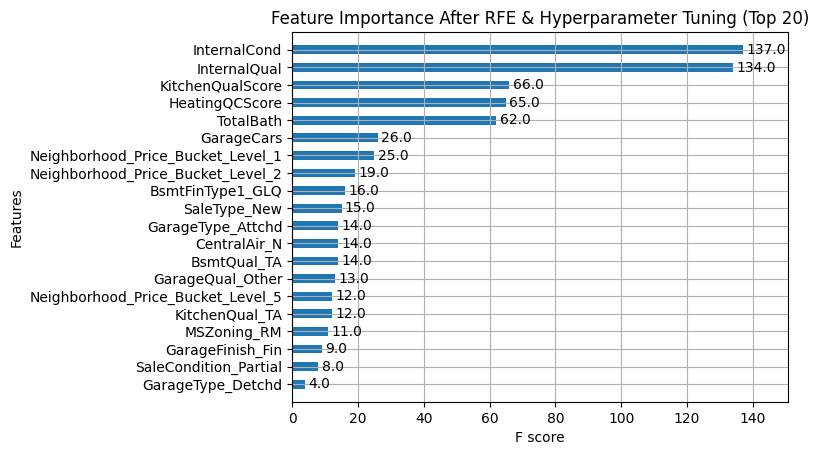

In [181]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.feature_selection import RFE
from sklearn.metrics import root_mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV
import xgboost as xgb

###############################################################################
# 1) RFE to select the top 20 features
###############################################################################
# Base XGBoost model for RFE (use default or minimal params)
base_model = xgb.XGBRegressor(objective='reg:squarederror', eval_metric='rmse')

# Apply RFE (Recursive Feature Elimination)
selector = RFE(base_model, n_features_to_select=20)
selector.fit(X_train_scaled, y_train)

# Get the mask of selected features
selected_features = X_train.columns[selector.support_]
print("Selected Features:", selected_features.tolist())

# Convert selected features into integer indices
selected_feature_indices = [X_train.columns.get_loc(f) for f in selected_features]

# Create NumPy arrays for the selected features
X_train_selected = X_train_scaled[:, selected_feature_indices]
X_test_selected = X_test_scaled[:, selected_feature_indices]

###############################################################################
# 2) Hyperparameter Tuning using GridSearchCV
###############################################################################
# Define parameter grid (you can adjust these as needed)
param_grid = {
    'max_depth': [3, 5],
    'learning_rate': [0.01, 0.1],
    'n_estimators': [100, 200],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# Create the model for grid search
xgb_model_for_search = xgb.XGBRegressor(objective='reg:squarederror', eval_metric='rmse')

# Set up GridSearchCV
grid_search = GridSearchCV(
    estimator=xgb_model_for_search,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',  # or 'r2', 'neg_mean_absolute_error', etc.
    cv=3,         # number of folds for cross-validation
    verbose=1,    # set to 0 or 2 depending on how much info you want
    n_jobs=-1     # use all available CPU cores
)

# Fit the grid search on the selected features
grid_search.fit(X_train_selected, y_train)

# Retrieve the best model
best_model = grid_search.best_estimator_
print("Best Hyperparameters:", grid_search.best_params_)

###############################################################################
# 3) Train (already done by grid_search) and Evaluate
###############################################################################
# Make predictions with the best model
y_pred = best_model.predict(X_test_selected)

# Calculate RMSE
rmse = root_mean_squared_error(y_test, y_pred)
# Calculate R²
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:,.2f}")
print(f"R² Score: {r2:.4f}")

###############################################################################
# 4) Fix Booster to Display Correct Feature Names
###############################################################################
# Get the booster from the best model
booster = best_model.get_booster()

# Manually assign the feature names so plot_importance can display them
booster.feature_names = selected_features.tolist()

###############################################################################
# 5) Plot Feature Importance
###############################################################################
plt.figure(figsize=(10, 6))
xgb.plot_importance(
    booster,
    importance_type='weight',
    max_num_features=20,
    show_values=True,
    height=0.5,
    xlabel='F score',
    title="Feature Importance After RFE & Hyperparameter Tuning (Top 20)"
)
plt.show()


### CART 

In [35]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# from sklearn.model_selection import train_test_split, RandomizedSearchCV
# from sklearn.tree import DecisionTreeRegressor  
# from sklearn.preprocessing import StandardScaler
# from sklearn.pipeline import Pipeline  
# from sklearn.metrics import mean_absolute_error
# from scipy.stats import randint, uniform  # Randomized distributions

# # Define features and target
# columns_to_include = df_final.columns.difference(['SalePrice'])
# X = df_final[columns_to_include]
# y = df_final['SalePrice']

# # Split data into training and testing sets
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# # Create a pipeline with scaling and the DecisionTreeRegressor
# pipeline = Pipeline([
#     ('scaler', StandardScaler()),
#     ('classifier', DecisionTreeRegressor(random_state=42))  
# ])

# # Randomized hyperparameter search space
# param_dist = {
#     'classifier__max_depth': randint(4, 15),  # Prevent overfitting
#     'classifier__min_samples_split': randint(5, 20),
#     'classifier__min_samples_leaf': randint(2, 10),  # More stable trees
#     'classifier__max_features': ['sqrt', 'log2'],  # Use subset of features
#     'classifier__criterion': ['squared_error', 'absolute_error'],
#     'classifier__min_impurity_decrease': uniform(0.0001, 0.001)  # Forces more meaningful splits
# }


# # Use RandomizedSearchCV for efficiency
# random_search = RandomizedSearchCV(
#     pipeline, param_distributions=param_dist, 
#     n_iter=15,  # Fewer iterations for speed
#     cv=3, scoring='neg_mean_absolute_error', 
#     n_jobs=-1, random_state=42, verbose=1
# )

# # Fit the model
# random_search.fit(X_train, y_train)

# # Best model evaluation on test set
# best_model = random_search.best_estimator_
# y_pred = best_model.predict(X_test)

# # Compute R^2 and MAE for evaluation
# test_r2 = best_model.score(X_test, y_test)
# # test_mae = mean_absolute_error(y_test, y_pred)

# print(f'Test R^2 Score: {test_r2:.4f}')

# # Extract feature importances
# dt_model = best_model.named_steps['classifier']
# importances = dt_model.feature_importances_
# indices = np.argsort(importances)[::-1]
# names = [columns_to_include[j] for j in indices]

# # Select **Top 20** most important features
# top_n = 20
# top_features = names[:top_n]
# top_importances = importances[indices][:top_n]

# # Plot Top 20 Feature Importances
# plt.figure(figsize=(12, 6))
# plt.barh(top_features, top_importances)
# plt.xlabel('Feature Importance')
# plt.ylabel('Feature')
# plt.title('Top 20 Feature Importances (Decision Tree Regressor)')
# plt.gca().invert_yaxis()
# plt.show()


### XGB Boost

Fitting 3 folds for each of 25 candidates, totalling 75 fits
Test R^2 Score: 0.9081


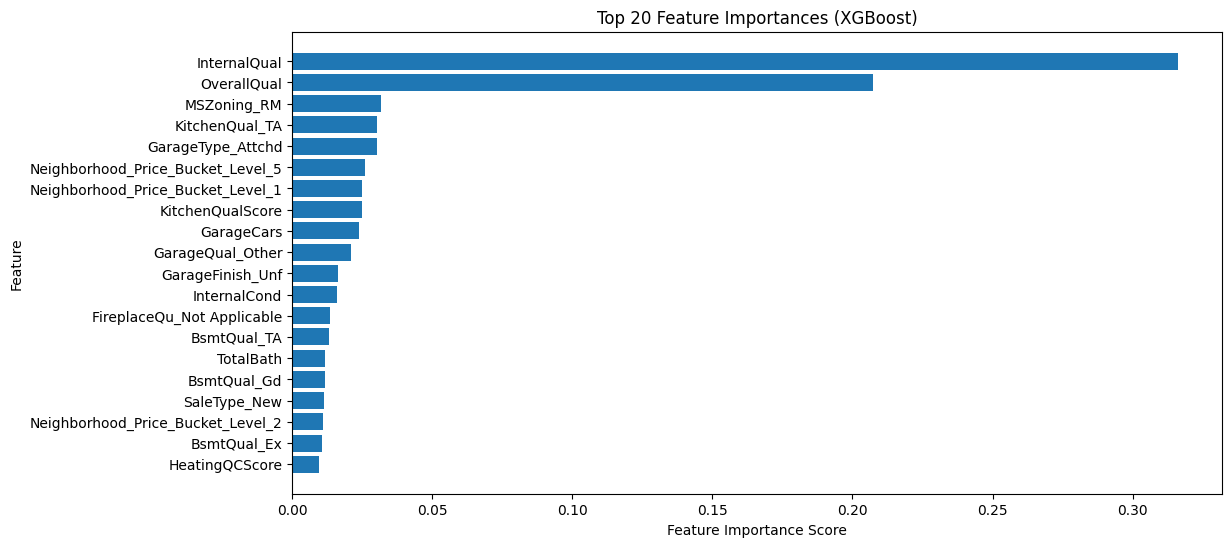

In [183]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from scipy.stats import uniform, randint

# Define features and target
columns_to_include = df.columns.difference(['SalePrice_Log'])
X = df[columns_to_include]
y = df['SalePrice_Log']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a pipeline with scaling and XGBoost Regressor
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', xgb.XGBRegressor(objective='reg:squarederror', eval_metric='rmse', 
                                    random_state=42, n_jobs=-1))
])

# RandomizedSearch with fewer parameter combinations
param_dist = {
    'classifier__max_depth': randint(4, 12),  
    'classifier__learning_rate': uniform(0.01, 0.1),  
    'classifier__n_estimators': randint(50, 200),  
    'classifier__subsample': uniform(0.7, 0.3),  
    'classifier__colsample_bytree': uniform(0.7, 0.3),  
    'classifier__reg_lambda': uniform(0.1, 10),  
    'classifier__reg_alpha': uniform(0, 1)
}

# Use RandomizedSearchCV instead of GridSearchCV
random_search = RandomizedSearchCV(
    pipeline, param_distributions=param_dist, 
    n_iter=25, cv=3, scoring='r2', n_jobs=-1, verbose=1, random_state=42
)  

# Fit with early stopping
random_search.fit(X_train, y_train)

# Best model evaluation on test set
best_model = random_search.best_estimator_
test_r2 = best_model.score(X_test, y_test)
print(f'Test R^2 Score: {test_r2:.4f}')

# Feature importance extraction
xgb_model = best_model.named_steps['classifier']
importances = xgb_model.feature_importances_
indices = np.argsort(importances)[::-1]
names = [columns_to_include[j] for j in indices]

# Select **Top 20** most important features
top_n = 20
top_features = names[:top_n]
top_importances = importances[indices][:top_n]

# Plot top 20 feature importances
plt.figure(figsize=(12, 6))
plt.barh(names[:20], importances[indices][:20])
plt.xlabel("Feature Importance Score")
plt.ylabel("Feature")
plt.title("Top 20 Feature Importances (XGBoost)")
plt.gca().invert_yaxis()
plt.show()



In [184]:
print(top_features)

['InternalQual', 'OverallQual', 'MSZoning_RM', 'KitchenQual_TA', 'GarageType_Attchd', 'Neighborhood_Price_Bucket_Level_5', 'Neighborhood_Price_Bucket_Level_1', 'KitchenQualScore', 'GarageCars', 'GarageQual_Other', 'GarageFinish_Unf', 'InternalCond', 'FireplaceQu_Not Applicable', 'BsmtQual_TA', 'TotalBath', 'BsmtQual_Gd', 'SaleType_New', 'Neighborhood_Price_Bucket_Level_2', 'BsmtQual_Ex', 'HeatingQCScore']


## Continuous Data

In [38]:
# Create a dataframe for the continuous variables
continuous_data = df.select_dtypes(include='number')

# drop the Id column
continuous_data.drop('Id', axis=1, inplace=True)

# Display the first 5 rows of the continuous data
continuous_data.head()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,InternalCond,HouseAge,RemodAge,GarageAge,ExterQaulScore,ExterCondScore,HeatingQCScore,KitchenQualScore,GarageQualScore,GarageCondScore
0,60,65.0,8450,7,5,2003,2003,196.0,706,0,...,12830,5,5,5.0,784.0,588.0,8550,6840,1644.0,1644.0
1,20,80.0,9600,6,8,1976,1976,0.0,978,0,...,20192,31,31,31.0,0.0,0.0,6310,3786,1380.0,1380.0
2,60,68.0,11250,7,5,2001,2002,162.0,486,0,...,13530,7,6,7.0,648.0,486.0,8930,7144,1824.0,1824.0
3,70,60.0,9550,7,5,1915,1970,0.0,216,0,...,12365,91,36,8.0,0.0,0.0,6868,6868,1926.0,1926.0
4,60,84.0,14260,8,5,2000,2000,350.0,655,0,...,16715,8,8,8.0,1400.0,1050.0,10990,8792,2508.0,2508.0


#### CART

Fitting 3 folds for each of 15 candidates, totalling 45 fits
Test R^2 Score: 0.7606


c:\Users\Carl\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py:540: FitFailedWarning: 
27 fits failed out of a total of 45.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
27 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\Carl\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\Carl\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py", line 1473, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Carl\AppData\Lo

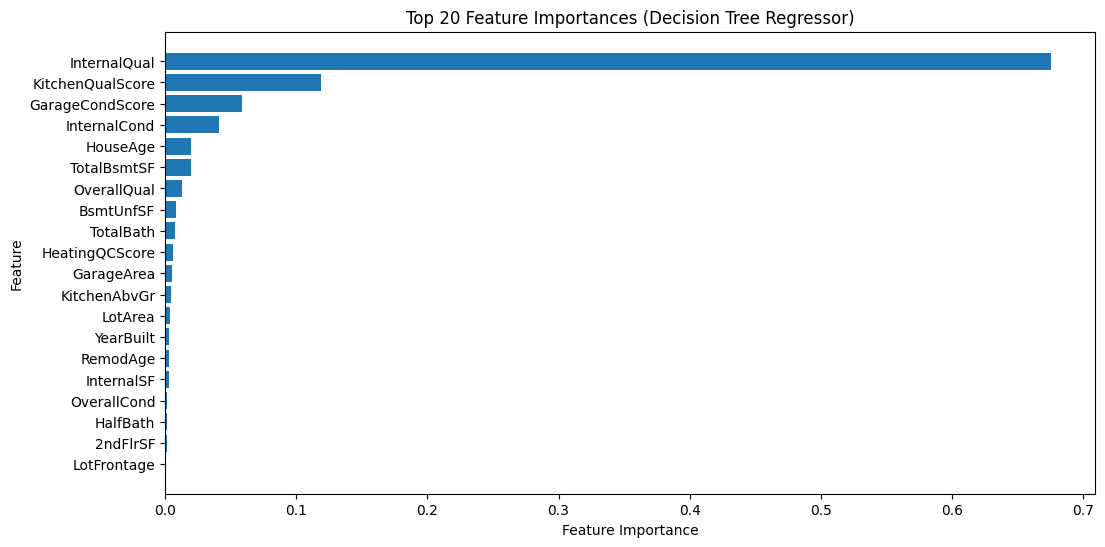

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.tree import DecisionTreeRegressor  
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline  
from sklearn.metrics import mean_absolute_error
from scipy.stats import randint, uniform  # Randomized distributions

# Define features and target
columns_to_include = continuous_data.columns.difference(['SalePrice'])
X = continuous_data[columns_to_include]
y = continuous_data['SalePrice']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a pipeline with scaling and the DecisionTreeRegressor
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', DecisionTreeRegressor(random_state=42))  
])

# Randomized hyperparameter search space
param_dist = {
    'classifier__max_depth': randint(4, 15),  # Prevent overfitting
    'classifier__min_samples_split': randint(5, 20),
    'classifier__min_samples_leaf': randint(2, 10),  # More stable trees
    'classifier__max_features': ['sqrt', 'log2'],  # Use subset of features
    'classifier__criterion': ['squared_error', 'absolute_error'],
    'classifier__min_impurity_decrease': uniform(0.0001, 0.001)  # Forces more meaningful splits
}


# Use RandomizedSearchCV for efficiency
random_search = RandomizedSearchCV(
    pipeline, param_distributions=param_dist, 
    n_iter=15,  # Fewer iterations for speed
    cv=3, scoring='neg_mean_absolute_error', 
    n_jobs=-1, random_state=42, verbose=1
)

# Fit the model
random_search.fit(X_train, y_train)

# Best model evaluation on test set
best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test)

# Compute R^2 and MAE for evaluation
test_r2 = best_model.score(X_test, y_test)
# test_mae = mean_absolute_error(y_test, y_pred)

print(f'Test R^2 Score: {test_r2:.4f}')

# Extract feature importances
dt_model = best_model.named_steps['classifier']
importances = dt_model.feature_importances_
indices = np.argsort(importances)[::-1]
names = [columns_to_include[j] for j in indices]

# Select **Top 20** most important features
top_n = 20
top_features = names[:top_n]
top_importances = importances[indices][:top_n]

# Plot Top 20 Feature Importances
plt.figure(figsize=(12, 6))
plt.barh(top_features, top_importances)
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Top 20 Feature Importances (Decision Tree Regressor)')
plt.gca().invert_yaxis()
plt.show()



#### XGB Boost

Fitting 3 folds for each of 25 candidates, totalling 75 fits
Test R^2 Score: 0.8897


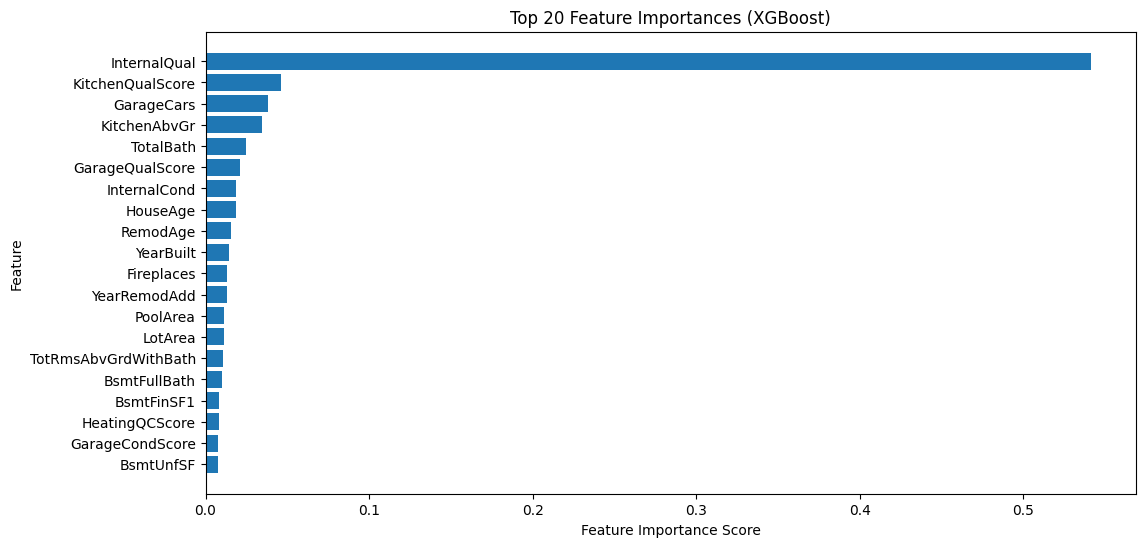

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from scipy.stats import uniform, randint

# Define features and target
columns_to_include = continuous_data.columns.difference(['SalePrice'])
X = continuous_data[columns_to_include]
y = continuous_data['SalePrice']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a pipeline with scaling and XGBoost Regressor
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', xgb.XGBRegressor(objective='reg:squarederror', eval_metric='rmse', 
                                    random_state=42, n_jobs=-1))
])

# RandomizedSearch with fewer parameter combinations
param_dist = {
    'classifier__max_depth': randint(4, 12),  
    'classifier__learning_rate': uniform(0.01, 0.1),  
    'classifier__n_estimators': randint(50, 200),  
    'classifier__subsample': uniform(0.7, 0.3),  
    'classifier__colsample_bytree': uniform(0.7, 0.3),  
    'classifier__reg_lambda': uniform(0.1, 10),  
    'classifier__reg_alpha': uniform(0, 1)
}

# Use RandomizedSearchCV instead of GridSearchCV
random_search = RandomizedSearchCV(
    pipeline, param_distributions=param_dist, 
    n_iter=25, cv=3, scoring='r2', n_jobs=-1, verbose=1, random_state=42
)  

# Fit with early stopping
random_search.fit(X_train, y_train)

# Best model evaluation on test set
best_model = random_search.best_estimator_
test_r2 = best_model.score(X_test, y_test)
print(f'Test R^2 Score: {test_r2:.4f}')

# Feature importance extraction
xgb_model = best_model.named_steps['classifier']
importances = xgb_model.feature_importances_
indices = np.argsort(importances)[::-1]
names = [columns_to_include[j] for j in indices]

# Select **Top 20** most important features
top_n = 20
top_features = names[:top_n]
top_importances = importances[indices][:top_n]

# Plot top 20 feature importances
plt.figure(figsize=(12, 6))
plt.barh(names[:20], importances[indices][:20])
plt.xlabel("Feature Importance Score")
plt.ylabel("Feature")
plt.title("Top 20 Feature Importances (XGBoost)")
plt.gca().invert_yaxis()
plt.show()


In [41]:
print(top_features)

['InternalQual', 'KitchenQualScore', 'GarageCars', 'KitchenAbvGr', 'TotalBath', 'GarageQualScore', 'InternalCond', 'HouseAge', 'RemodAge', 'YearBuilt', 'Fireplaces', 'YearRemodAdd', 'PoolArea', 'LotArea', 'TotRmsAbvGrdWithBath', 'BsmtFullBath', 'BsmtFinSF1', 'HeatingQCScore', 'GarageCondScore', 'BsmtUnfSF']


## Categorical Data

In [42]:
# Get categorical columns to encode (excluding 'SalePrice')
cols_to_encode = df.select_dtypes(include=['object'])

def encode_columns(df, cols_to_encode):
    ohe = OneHotEncoder(sparse_output=False)  # Fix: Use sparse_output=False
    df_encoded = df.copy()
    
    for col in cols_to_encode:
        Xd = ohe.fit_transform(df_encoded[[col]])  # One-hot encode the column
        unique_values = ohe.categories_[0]  # Get unique category names
        new_cols = [f"{col}_{val}" for val in unique_values]  # Create new column names
        
        # Create a new DataFrame for encoded columns
        df_ohe = pd.DataFrame(Xd, columns=new_cols, index=df_encoded.index)
        
        # Concatenate with the original DataFrame
        df_encoded = pd.concat([df_encoded, df_ohe], axis=1)

    # Drop original categorical columns
    df_encoded.drop(cols_to_encode, axis=1, inplace=True)
    
    return df_encoded

# Encode the categorical dataset
df_encoded = encode_columns(categorical_data, cols_to_encode)

# Merge the categorical and continuous data to show the 'SalePrice' column
df_encoded = pd.concat([df_encoded, df['SalePrice']], axis=1)

# Display the first 5 rows of the encoded dataset
df_encoded.head()

,MSZoning_C (all),MSZoning_FV,MSZoning_RH,MSZoning_RL,MSZoning_RM,Street_Grvl,Street_Pave,Alley_Grvl,Alley_Not Applicable,Alley_Pave,...,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial,Neighborhood_Price_Bucket_Level_1,Neighborhood_Price_Bucket_Level_2,Neighborhood_Price_Bucket_Level_3,Neighborhood_Price_Bucket_Level_4,SalePrice
0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,208500
1,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,181500
2,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,223500
3,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,140000
4,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,250000


### CART

Fitting 3 folds for each of 15 candidates, totalling 45 fits
Test R^2 Score: 0.4996


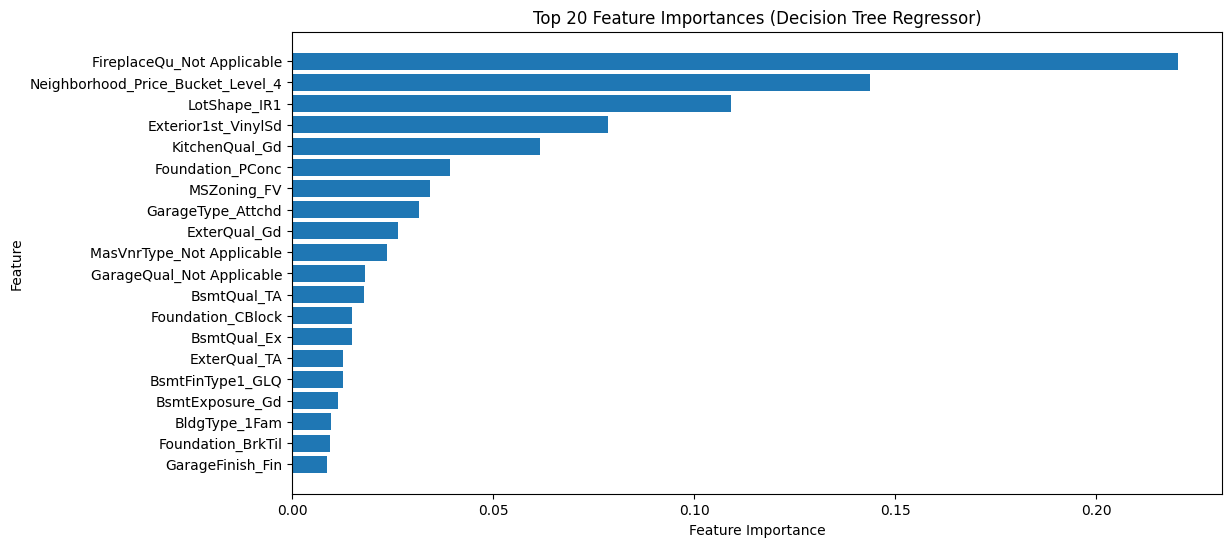

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.tree import DecisionTreeRegressor  
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline  
from sklearn.metrics import mean_absolute_error
from scipy.stats import randint, uniform  # Randomized distributions

# Define features and target
columns_to_include = df_encoded.columns.difference(['SalePrice'])
X = df_encoded[columns_to_include]
y = df_encoded['SalePrice']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a pipeline with scaling and the DecisionTreeRegressor
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', DecisionTreeRegressor(random_state=42))  
])

# Randomized hyperparameter search space
param_dist = {
    'classifier__max_depth': randint(4, 15),  # Prevent overfitting
    'classifier__min_samples_split': randint(5, 20),
    'classifier__min_samples_leaf': randint(2, 10),  # More stable trees
    'classifier__max_features': ['sqrt', 'log2'],  # Use subset of features
    'classifier__criterion': ['squared_error', 'absolute_error'],
    'classifier__min_impurity_decrease': uniform(0.0001, 0.001)  # Forces more meaningful splits
}


# Use RandomizedSearchCV for efficiency
random_search = RandomizedSearchCV(
    pipeline, param_distributions=param_dist, 
    n_iter=15,  # Fewer iterations for speed
    cv=3, scoring='neg_mean_absolute_error', 
    n_jobs=-1, random_state=42, verbose=1
)

# Fit the model
random_search.fit(X_train, y_train)

# Best model evaluation on test set
best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test)

# Compute R^2 and MAE for evaluation
test_r2 = best_model.score(X_test, y_test)
# test_mae = mean_absolute_error(y_test, y_pred)

print(f'Test R^2 Score: {test_r2:.4f}')

# Extract feature importances
dt_model = best_model.named_steps['classifier']
importances = dt_model.feature_importances_
indices = np.argsort(importances)[::-1]
names = [columns_to_include[j] for j in indices]

# Select **Top 20** most important features
top_n = 20
top_features = names[:top_n]
top_importances = importances[indices][:top_n]

# Plot Top 20 Feature Importances
plt.figure(figsize=(12, 6))
plt.barh(top_features, top_importances)
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Top 20 Feature Importances (Decision Tree Regressor)')
plt.gca().invert_yaxis()
plt.show()


#### XG Boost

Fitting 3 folds for each of 25 candidates, totalling 75 fits
Test R^2 Score: 0.7753


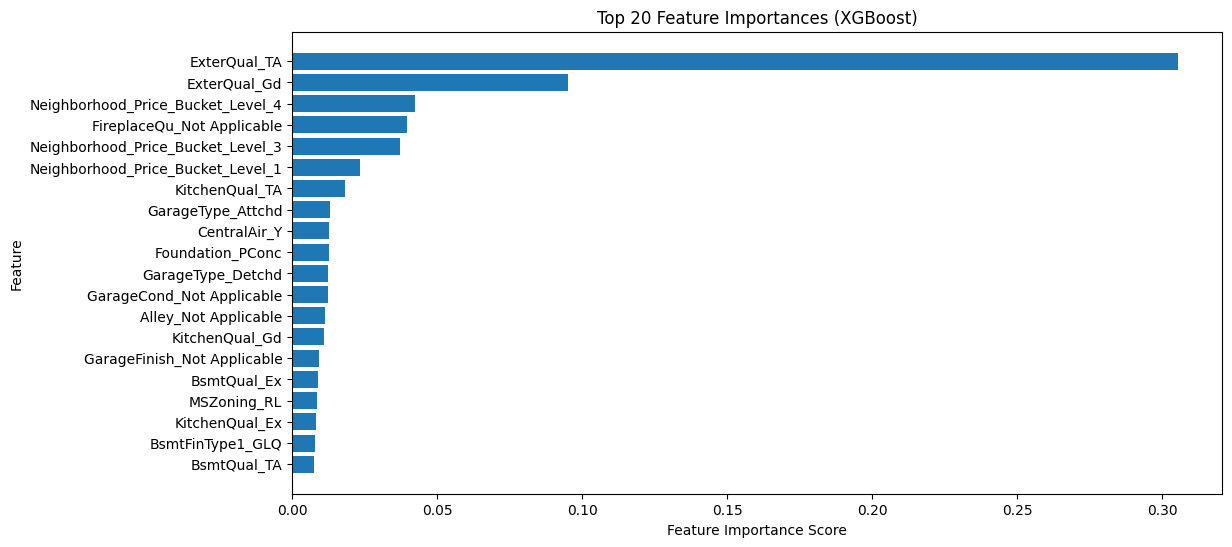

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from scipy.stats import uniform, randint

# Define features and target
columns_to_include = df_encoded.columns.difference(['SalePrice'])
X = df_encoded[columns_to_include]
y = df_encoded['SalePrice']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a pipeline with scaling and XGBoost Regressor
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', xgb.XGBRegressor(objective='reg:squarederror', eval_metric='rmse', 
                                    random_state=42, n_jobs=-1))
])

# RandomizedSearch with fewer parameter combinations
param_dist = {
    'classifier__max_depth': randint(4, 12),  
    'classifier__learning_rate': uniform(0.01, 0.1),  
    'classifier__n_estimators': randint(50, 200),  
    'classifier__subsample': uniform(0.7, 0.3),  
    'classifier__colsample_bytree': uniform(0.7, 0.3),  
    'classifier__reg_lambda': uniform(0.1, 10),  
    'classifier__reg_alpha': uniform(0, 1)
}

# Use RandomizedSearchCV instead of GridSearchCV
random_search = RandomizedSearchCV(
    pipeline, param_distributions=param_dist, 
    n_iter=25, cv=3, scoring='r2', n_jobs=-1, verbose=1, random_state=42
)  

# Fit with early stopping
random_search.fit(X_train, y_train)

# Best model evaluation on test set
best_model = random_search.best_estimator_
test_r2 = best_model.score(X_test, y_test)
print(f'Test R^2 Score: {test_r2:.4f}')

# Feature importance extraction
xgb_model = best_model.named_steps['classifier']
importances = xgb_model.feature_importances_
indices = np.argsort(importances)[::-1]
names = [columns_to_include[j] for j in indices]

# Select **Top 20** most important features
top_n = 20
top_features = names[:top_n]
top_importances = importances[indices][:top_n]

# Plot top 20 feature importances
plt.figure(figsize=(12, 6))
plt.barh(names[:20], importances[indices][:20])
plt.xlabel("Feature Importance Score")
plt.ylabel("Feature")
plt.title("Top 20 Feature Importances (XGBoost)")
plt.gca().invert_yaxis()
plt.show()


In [45]:
print(top_features)

['ExterQual_TA', 'ExterQual_Gd', 'Neighborhood_Price_Bucket_Level_4', 'FireplaceQu_Not Applicable', 'Neighborhood_Price_Bucket_Level_3', 'Neighborhood_Price_Bucket_Level_1', 'KitchenQual_TA', 'GarageType_Attchd', 'CentralAir_Y', 'Foundation_PConc', 'GarageType_Detchd', 'GarageCond_Not Applicable', 'Alley_Not Applicable', 'KitchenQual_Gd', 'GarageFinish_Not Applicable', 'BsmtQual_Ex', 'MSZoning_RL', 'KitchenQual_Ex', 'BsmtFinType1_GLQ', 'BsmtQual_TA']


## Notes on Feature Engineering

In trying to determine was features that were the most relevant, I applied to models CART and XGBoost.

In addition to using two models, I also executed the models on all the features and a split between continuous and categorical features, to determine if there is a benefit to running them seperately.

Based on the results in terms of the R<sup>2</sup> score was:

1. XG Boost - All Variables 0.8932
2. XG Boost - Continuous Variables 0.8701
3. XG Boost - Categorical Data 0.7763